In [4]:
import pandas as pd
import numpy as np

In [5]:
credits = pd.read_csv("Customer_Data.csv")

In [6]:
credits.head(15)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONE_OFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONE_OFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [7]:
# BALANCE - Saldo total da conta do ID
# BALANCE_FREQUENCY - Frequência que ele usa esse saldo. indo de 0.0 até 1.0
# PURCHASES - Compra que a pessoa fez
# ONE_OFF_PURCHASES - Compras feita á vista
# INSTALLMENTS_PURCHASES - Compras Parceladas, Ex: c10007 - A compra foi 7,091,00 R$ mas pagou 6,402,00 R$ e parcelou o restante dos 688,38 R$
# PURCHASES_FREQUENCY - Frequência que a pessoa compra
# ONE_OFF_PURCHASES_FREQUENCY - Frequência que a pessoa compra á vista
# PURCHASES_INSTALLMENTS_FREQUENCY - Frequência que a pessoa compra parcelado
# CASH_ADVANCE_FREQUENCY - Frequência que a pessoa usa o límite do cartão para sacar em dinheiro
# CREDIT_LIMIT - Limite do cartão
# PAYMENTS - O que a pessoa precisa pagar do cartão
# MINIMUM_PAYMENTS - O valor mínimo que a pessoa precisa pagar da parcela

credits = credits.drop(
["CASH_ADVANCE_TRX", "CASH_ADVANCE", "TENURE", "PRC_FULL_PAYMENT"], axis=1
)


In [8]:
colunas = [
    "BALANCE",
    "BALANCE_FREQUENCY",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "CREDIT_LIMIT"
]

credits.describe().T



,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONE_OFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONE_OFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000
PURCHASES_TRX,8950.0,14.709832,24.857649,0.000000,1.000000,7.000000,17.000000,358.00000


In [12]:
credits["PURCHASES_FREQUENCY"].describe()

count    8950.000000
mean        0.490351
std         0.401371
min         0.000000
25%         0.083333
50%         0.500000
75%         0.916667
max         1.000000
Name: PURCHASES_FREQUENCY, dtype: float64

In [13]:

   credits['ONE_OFF_PURCHASES_FREQUENCY'].describe()

count    8950.000000
mean        0.202458
std         0.298336
min         0.000000
25%         0.000000
50%         0.083333
75%         0.300000
max         1.000000
Name: ONE_OFF_PURCHASES_FREQUENCY, dtype: float64

In [16]:
credits['PURCHASES_INSTALLMENTS_FREQUENCY'].describe()
  

count    8950.000000
mean        0.364437
std         0.397448
min         0.000000
25%         0.000000
50%         0.166667
75%         0.750000
max         1.000000
Name: PURCHASES_INSTALLMENTS_FREQUENCY, dtype: float64

In [7]:
credits["TAXA_USO_LIMITE"] = credits["BALANCE"] / credits["CREDIT_LIMIT"]
credits.head(15)
credits[["BALANCE", "PAYMENTS","PURCHASES", "MINIMUM_PAYMENTS","TAXA_USO_LIMITE"]].round(2)



,BALANCE,PAYMENTS,PURCHASES,MINIMUM_PAYMENTS,TAXA_USO_LIMITE
0,40.90,201.80,95.40,139.51,0.04
1,3202.47,4103.03,0.00,1072.34,0.46
2,2495.15,622.07,773.17,627.28,0.33
3,1666.67,0.00,1499.00,NaN,0.22
4,817.71,678.33,16.00,244.79,0.68
...,...,...,...,...,...
8945,28.49,325.59,291.12,48.89,0.03
8946,19.18,275.86,300.00,NaN,0.02
8947,23.40,81.27,144.40,82.42,0.02
8948,13.46,52.55,0.00,55.76,0.03


In [8]:
credits["TAXA_USO_LIMITE"].describe()

count    8949.000000
mean        0.388926
std         0.389722
min         0.000000
25%         0.041527
50%         0.302870
75%         0.717582
max        15.909951
Name: TAXA_USO_LIMITE, dtype: float64

In [9]:
# Identifica se o cliente prefere comprar mais à vista ou parcelado
condicoes = [
    (credits["ONE_OFF_PURCHASES"] > credits["INSTALLMENTS_PURCHASES"]),
    (credits["INSTALLMENTS_PURCHASES"] > credits["ONE_OFF_PURCHASES"])
]
escolhas = ['Predominio A Vista', 'Predominio Parcelado']
credits['PERFIL_COMPRA'] = np.select(condicoes, escolhas, default='Neutro / Sem Compras')



In [10]:
credits["PERFIL_COMPRA"].describe()

count                   8950
unique                     3
top       Predominio A Vista
freq                    3498
Name: PERFIL_COMPRA, dtype: object

In [11]:
# Proporção entre o que o cliente pagou e o mínimo exigido
credits['RAZAO_PAGAMENTO_MINIMO'] = credits['PAYMENTS'] / credits['MINIMUM_PAYMENTS']


In [12]:
credits["RAZAO_PAGAMENTO_MINIMO"].describe().T

count    8637.000000
mean        9.350070
std       120.286915
min         0.000730
25%         0.957549
50%         2.170495
75%         6.260430
max      6840.528861
Name: RAZAO_PAGAMENTO_MINIMO, dtype: float64

<Axes: >

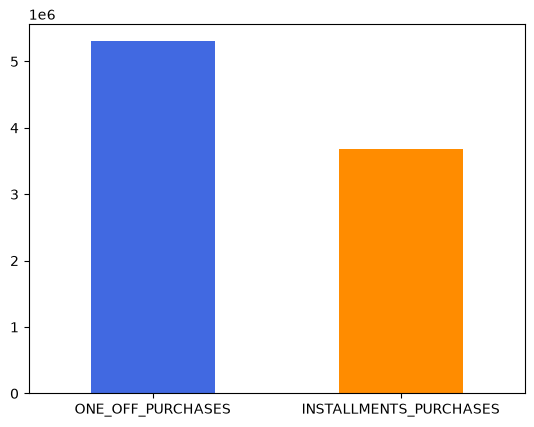

In [31]:
credits[['ONE_OFF_PURCHASES', 'INSTALLMENTS_PURCHASES']].sum().plot(
    kind='bar', color=['royalblue', 'darkorange'], rot=0
)


<Axes: ylabel='Frequency'>

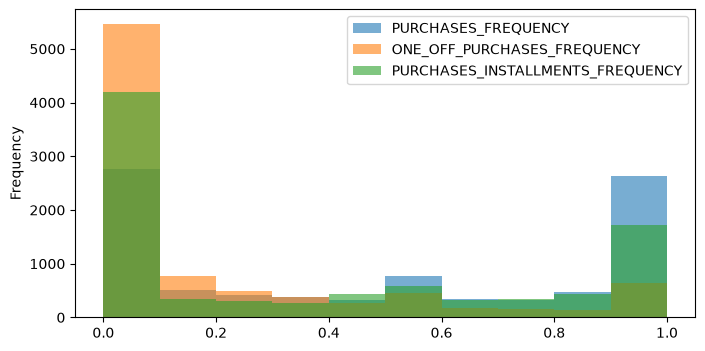

In [35]:
credits[[
    'PURCHASES_FREQUENCY',
    'ONE_OFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
]].plot(kind='hist', alpha=0.6, bins=10, figsize=(8, 4))

<Axes: >

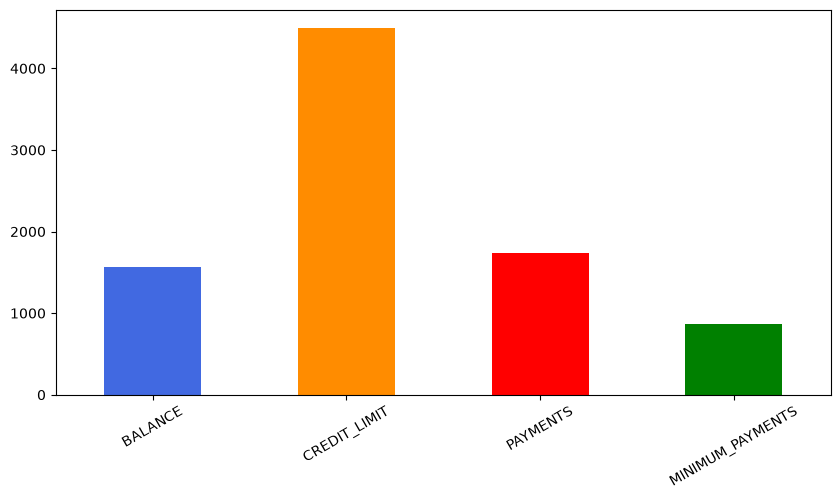

In [24]:
credits[[
    'BALANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
]].mean().plot(
    kind='bar',
    color=['royalblue', 'darkorange', 'red', 'green', 'purple'],
    figsize=(10, 5),
    rot=30,
)

In [25]:
credits["BALANCE"].describe().T

count     8950.000000
mean      1564.474828
std       2081.531879
min          0.000000
25%        128.281915
50%        873.385231
75%       2054.140036
max      19043.138560
Name: BALANCE, dtype: float64

In [26]:
credits["CREDIT_LIMIT"].describe().T

count     8949.000000
mean      4494.449450
std       3638.815725
min         50.000000
25%       1600.000000
50%       3000.000000
75%       6500.000000
max      30000.000000
Name: CREDIT_LIMIT, dtype: float64

In [27]:
credits["PAYMENTS"].describe().T

count     8950.000000
mean      1733.143852
std       2895.063757
min          0.000000
25%        383.276166
50%        856.901546
75%       1901.134317
max      50721.483360
Name: PAYMENTS, dtype: float64

In [28]:
credits["MINIMUM_PAYMENTS"].describe().T

count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: MINIMUM_PAYMENTS, dtype: float64